# Home assigment 1

Please give your name below:

In [ ]:
name='Lovisa'

# Exercise 3

You will work a bit more with reading ASCII files (I can attest, this is a routine daily task for a nuclear reactor analyst). In the attached folder (called 'train') you find several spent nuclear fuel inventories generated with the Monte Carlo transport code Serpent2. You will learn later during the course more about spent nuclear fuel, in this exercise you will need to focus only on scripting. The naming convention of the files within the folder describes the burnup or BU (ie. how long the fuel was in the reactor, and how much energy was released from it) and cooling time or CT (ie. how long the fuel was cooled after irradiation): for example 'trainBU46.00CT26.18.bumat2' belongs to a case where the burnup was 46.00 MWd/kgU and the fuel was cooled for 26.18 years after leaving the reactor. Note, that the files also contain burnup and time information, however that time is not just the cooling time, it also includes the time the fuel spent in the reactor.

The isotopes are listed with their ZAID (ie. an ID constructed as $Z\cdot1000+A$) in the files, all ending with '.15c' which refers to the temperature in the calculation, not relevant for your task. For example U235 you will find as '92235.15c'. The inventory is given as atomic concentrations for each nuclide with units $b^{-1}cm^{-1}=\frac{1}{b\cdot cm}=\frac{1}{10^{-24}cm^3}=\frac{10^{24}}{cm^3}$.  

1. Write a function which receives a filename as an input and then extracts the file content into a dictionary. Store both the concentrations and the burnup/cooling time information based on the filenames. Then apply this function to all the files (hint: you can use `os.listdir(foldername)` to list the files in the folder, for this you have to `import os`. You can read about the `os` package at [the documentation site](https://docs.python.org/3/library/os.html).)

2. Plot the concentration of Cs-137 against burnup with 'x' markers. Use 
    - blue marker if the cooling time is between 5 and 10 years.
    - red marker if the cooling time is between 10 and 15 years.
    - green marker if the cooling time is between 15 and 20 years
    - yellow marker if the cooling time is between 20 and 25 years
    - magenta marker if the cooling time is above 25 years
    - (Note you can use other colors if you prefer so, the important part is to use 5 distinct colors for these cooling time intervals).

3. Convert the concentrations to activity concentration (Bq/cm3) for Cs137, Cs134 and Eu154 (hint: you can look up the half-lifes from the internet, and make sure that you convert the units correctly). 
    - Plot the activity concentrations against burnup for the three isotopes in one figure. Use a legend.
    - Plot the activity concentrations after the fuel was removed from the reactor against burnup for the three isotopes in one figure. Use a legend. (Hint, you will need to use the cooling time information, and the decay law to figure out what was the activity before the cooling has started.)
    
4. Write a few sentences about your conclusions.

In [27]:
import os
import numpy as np
import re
import matplotlib.pyplot as plt
def extract_data(filename):
    data = {}
    # Extracts burnup (BU) and cooling time (CT) from the file name and reads the inventory data.
    match = re.search(r'BU(\d+\.\d+)CT(\d+\.\d+)', filename)
    data['BU'] = float(match.group(1)) if match else None
    data['CT'] = float(match.group(2)) if match else None

    with open(filename, 'r') as file:
        file_data = file.readlines()
        
    data['inventory'] = {}
    for line in file_data[7:-1]: # Skip the first 7 lines since they are headers
        ZAID = int(line.split('.')[0].strip())
        conc = float(line.split()[1]) 
        data['inventory'][ZAID] = conc
    return data

# Function to read all .bumat2 files in the 'train' directory and extract their data.
def read_all_data():
    data_list = []
    for file in os.listdir('train'):
        if file.endswith('.bumat2'):
            file_path = os.path.join('train', file)
            data = extract_data(file_path)
            data_list.append(data)
    return data_list
BU_conc_data = read_all_data()
print(BU_conc_data)


[{'BU': 10.23, 'CT': 5.4, 'inventory': {1002: 3.82231941247993e-10, 1003: 1.59760519566215e-13, 2003: 6.00180557241414e-14, 2004: 1.2543765566227e-06, 3006: 6.77012643119392e-18, 3007: 2.72655672631062e-21, 4009: 1.97705759780431e-13, 5010: 1.15168168339935e-24, 5011: 2.31706453843587e-17, 6012: 3.55772180418091e-09, 7014: 1.98773272815453e-13, 7015: 4.29714455816313e-10, 8016: 0.0468481217225127, 8017: 4.73455885157957e-09, 31069: 1.78921940924703e-16, 31071: 9.72246122591486e-14, 32070: 3.14471307956331e-18, 32072: 2.156690907548e-10, 32073: 5.34920539803207e-10, 32074: 1.30695297576816e-09, 32076: 8.69099196283997e-09, 33074: 3.23192626680059e-15, 33075: 3.29946930266548e-09, 34074: 1.24735246915419e-19, 34076: 2.85170105341846e-11, 34077: 2.08499168398773e-08, 34078: 5.45305795648973e-08, 34079: 1.157525988436e-07, 34080: 3.13462912045347e-07, 34082: 7.90998626094125e-07, 35079: 1.44793027407682e-11, 35081: 5.03758859852017e-07, 36078: 1.14166284285776e-20, 36080: 9.19892387224304e

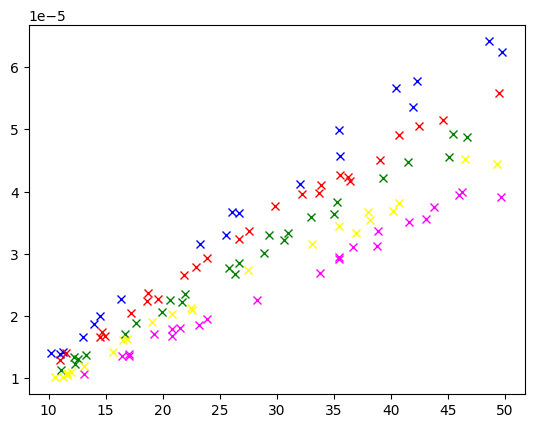

In [ ]:

ZAID_Cs137 = 55137


plt.figure()

for item in BU_conc_data:
    BU = item['BU']
    conc_C137 = item['inventory'][ZAID_Cs137]
    CT = item['CT']
    if CT < 10 and CT > 5:
        color= 'blue'
    elif CT < 15 and CT > 10:
        color= 'red'
    elif CT < 20 and CT > 15:
        color= 'green'
    elif CT < 25 and CT > 20:
        color= 'yellow'
    elif CT > 25:
        color= 'magenta'
    plt.plot(BU, conc_C137, 'x', color=color)
plt.show()


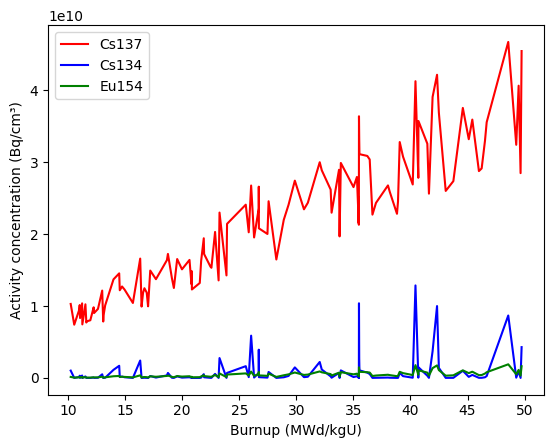

In [41]:
import pandas as pd
# Activity concentration = atom concentration * lambda
# Activity concentration (Bq/cm3) for Cs137, Cs134 and Eu154

lam_Cs137 = np.log(2)/(30.17*60*60*24*365)*10**(24)
lam_Cs134 = np.log(2)/(2.06*60*60*24*365)*10**(24)
lam_Eu154 = np.log(2)/(8.6*60*60*24*365)*10**(24)

ZAID_Cs137 = 55137
ZAID_Cs134 = 55134
ZAID_Eu154 = 63154

data = {'BU': [], 'A_conc_Cs137': [], 'A_conc_Cs134': [], 'A_conc_Eu154': [],}


for item in BU_conc_data:
    data['BU'].append(item['BU'])
    data['A_conc_Cs137'].append(item['inventory'][ZAID_Cs137]*lam_Cs137)
    data['A_conc_Cs134'].append(item['inventory'][ZAID_Cs134]*lam_Cs134)
    data['A_conc_Eu154'].append(item['inventory'][ZAID_Eu154]*lam_Eu154)


plt.figure()
plt.plot(data['BU'], data['A_conc_Cs137'], color='red', label='Cs137')
plt.plot(data['BU'], data['A_conc_Cs134'], color='blue', label='Cs134')
plt.plot(data['BU'], data['A_conc_Eu154'], color='green', label='Eu154')
plt.legend()
plt.xlabel('Burnup (MWd/kgU)')
plt.ylabel('Activity concentration (Bq/cm³)')
plt.show()



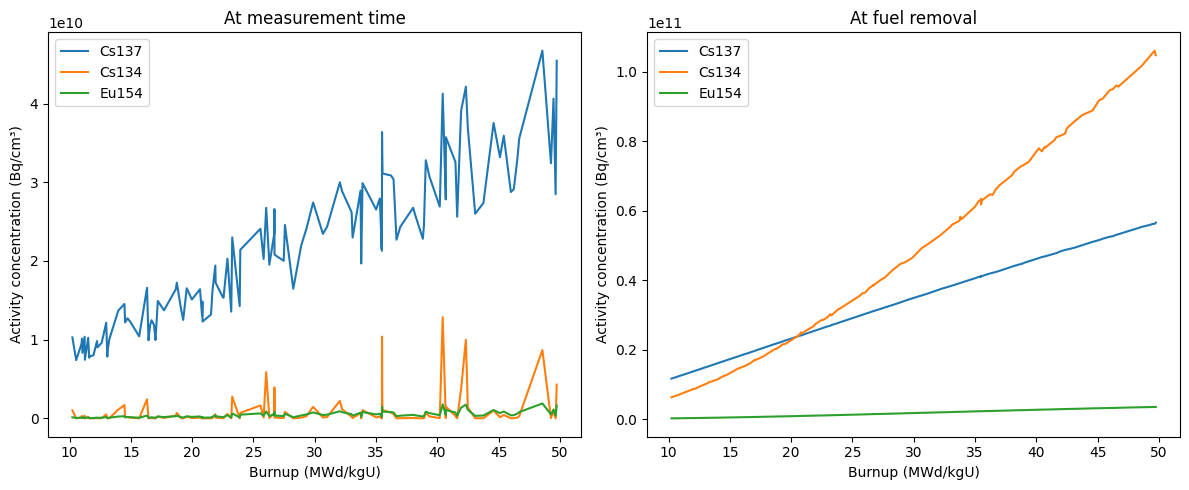

In [47]:
import pandas as pd

nuclides = {
    'Cs137': {'ZAID': 55137, 'half_life': 30.17 * 60 * 60 * 24 * 365},
    'Cs134': {'ZAID': 55134, 'half_life': 2.06  * 60 * 60 * 24 * 365},
    'Eu154': {'ZAID': 63154, 'half_life': 8.6   * 60 * 60 * 24 * 365},
}

for name, props in nuclides.items():
    props['lam'] = np.log(2) / props['half_life']

data = {'BU': [], **{f'A_conc_{name}': [] for name in nuclides}, **{f'A_conc_{name}_at_removal': [] for name in nuclides}}

for item in BU_conc_data:
    data['BU'].append(item['BU'])
    for name, props in nuclides.items():
        CT_seconds = item['CT'] * 365 * 24 * 3600
        N = item['inventory'][props['ZAID']]
        lam = props['lam']
        data[f'A_conc_{name}'].append(N * lam * 1e24)
        data[f'A_conc_{name}_at_removal'].append(N * np.exp(lam * CT_seconds) * lam * 1e24)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for name in nuclides:
    ax1.plot(data['BU'], data[f'A_conc_{name}'], label=name)
ax1.set_xlabel('Burnup (MWd/kgU)')
ax1.set_ylabel('Activity concentration (Bq/cm³)')
ax1.set_title('At measurement time')
ax1.legend()

for name in nuclides:
    ax2.plot(data['BU'], data[f'A_conc_{name}_at_removal'], label=name)
ax2.set_xlabel('Burnup (MWd/kgU)')
ax2.set_ylabel('Activity concentration (Bq/cm³)')
ax2.set_title('At fuel removal')
ax2.legend()

plt.tight_layout()
plt.show()